# Plant 1 — Complete Week 1 Data Science + Member 4 Integration + AI/ML Handoff

## Single handover notebook for the Plant 1 AI/ML member

This notebook combines the existing **Plant 1 Generation** notebook, **Plant 1 Weather** notebook, and the **Member 4 final integration layer** into one continuous workflow.

### Workflow
1. Plant 1 generation cleaning, validation and EDA
2. Plant 1 weather-sensor cleaning, validation and EDA
3. Member 4 integration of generation + weather + Open-Meteo
4. Final 15-minute inverter-level, 15-minute plant-level and hourly AI/ML handoff datasets
5. Validation and export

**The AI/ML member can continue from the final integration section in this same notebook.**

### Recommended starting dataset
`plant1_ai_ml_handoff_hourly.csv` — plant-level hourly generation + weather/Open-Meteo features.


## 0. Imports, paths and shared configuration


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Dynamic directory resolution for local IDE (root or notebooks/) and Google Colab (/content)
def resolve_dir(candidates, default):
    for c in candidates:
        if c.exists():
            return c
    return default

DATA_DIR = resolve_dir([
    Path("data/raw"),
    Path("../data/raw"),
    Path("/content/data/raw"),
    Path("/content"),
    Path("/mnt/data")
], default=Path("data/raw"))

OUTPUT_DIR = resolve_dir([
    Path("data/processed"),
    Path("../data/processed"),
    Path("/content/data/processed")
], default=Path("data/processed"))

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve() if DATA_DIR.exists() else DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve() if OUTPUT_DIR.exists() else OUTPUT_DIR)


DATA_DIR: /content
OUTPUT_DIR: /content/plant1_final_ai_ml_handoff


## 1. Plant 1 Generation — cleaning, validation and EDA


In [42]:
DATA_FILE = DATA_DIR / "Plant_1_Generation_Data.csv"
print("Generation input:", DATA_FILE)


Generation input: /content/Plant_1_Generation_Data.csv


## 2. Load raw Plant 1 generation data

In [43]:
plant1_raw = pd.read_csv(DATA_FILE)

print("Shape:", plant1_raw.shape)
display(plant1_raw.head())
plant1_raw.info()


Shape: (59565, 7)


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0000,0.0000,0.0000,"6,259,559.0000"
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0000,0.0000,0.0000,"6,183,645.0000"
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0000,0.0000,0.0000,"6,987,759.0000"
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0000,0.0000,0.0000,"7,602,960.0000"
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0000,0.0000,0.0000,"7,158,964.0000"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59565 entries, 0 to 59564
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    59565 non-null  object 
 1   PLANT_ID     59565 non-null  int64  
 2   SOURCE_KEY   59565 non-null  object 
 3   DC_POWER     59565 non-null  float64
 4   AC_POWER     59565 non-null  float64
 5   DAILY_YIELD  59565 non-null  float64
 6   TOTAL_YIELD  59564 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.2+ MB


## 3. Preserve raw data and standardize columns

In [44]:
plant1 = plant1_raw.copy()
plant1.columns = [c.strip().upper() for c in plant1.columns]
display(plant1.head())
print("Columns:", plant1.columns.tolist())


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0000,0.0000,0.0000,"6,259,559.0000"
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0000,0.0000,0.0000,"6,183,645.0000"
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0000,0.0000,0.0000,"6,987,759.0000"
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0000,0.0000,0.0000,"7,602,960.0000"
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0000,0.0000,0.0000,"7,158,964.0000"


Columns: ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']


## 4. Data-quality checks

In [45]:
missing = plant1.isna().sum().sort_values(ascending=False)
print("Missing values:")
display(missing.to_frame("missing_count"))

print("Exact duplicate rows:", plant1.duplicated().sum())
display(plant1.dtypes.to_frame("dtype"))
display(plant1.describe(include="all").T)


Missing values:


,missing_count
TOTAL_YIELD,1
PLANT_ID,0
DATE_TIME,0
SOURCE_KEY,0
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0


Exact duplicate rows: 0


,dtype
DATE_TIME,object
PLANT_ID,int64
SOURCE_KEY,object
DC_POWER,float64
AC_POWER,float64
DAILY_YIELD,float64
TOTAL_YIELD,float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DATE_TIME,59565,2740,13-06-2020 14:30,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PLANT_ID,"59,565.0000",NaN,NaN,NaN,"4,135,001.0000",0.0000,"4,135,001.0000","4,135,001.0000","4,135,001.0000","4,135,001.0000","4,135,001.0000"
SOURCE_KEY,59565,22,1BY6WEcLGh8j5v7,2736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DC_POWER,"59,565.0000",NaN,NaN,NaN,"3,219.4835","4,095.3555",0.0000,0.0000,464.1429,"6,513.1429","14,413.4286"
AC_POWER,"59,565.0000",NaN,NaN,NaN,314.8216,400.1146,0.0000,0.0000,44.9000,637.7375,"1,405.3000"
DAILY_YIELD,"59,565.0000",NaN,NaN,NaN,"3,240.2126","3,155.0666",0.0000,0.0000,"2,425.2857","6,265.4286","9,163.0000"
TOTAL_YIELD,"59,564.0000",NaN,NaN,NaN,"6,962,462.3559","414,710.0505","6,183,645.0000","6,486,005.9910","7,133,897.0000","7,250,523.3925","7,819,361.4290"


## 5. Parse timestamp and validate time coverage

In [46]:
plant1["DATE_TIME"] = pd.to_datetime(
    plant1["DATE_TIME"],
    dayfirst=True,
    errors="coerce"
)

# Drop rows where DATE_TIME is null before sorting and resetting index
plant1 = plant1.dropna(subset=["DATE_TIME"]).reset_index(drop=True)

print("Invalid timestamps after drop:", plant1["DATE_TIME"].isna().sum())
print("Start:", plant1["DATE_TIME"].min())
print("End:", plant1["DATE_TIME"].max())
print("Unique timestamps:", plant1["DATE_TIME"].nunique())

plant1 = plant1.sort_values(["DATE_TIME", "SOURCE_KEY"]).reset_index(drop=True)
display(plant1[["DATE_TIME", "SOURCE_KEY", "DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD"]].head())

Invalid timestamps after drop: 0
Start: 2020-05-15 00:00:00
End: 2020-06-13 14:45:00
Unique timestamps: 2740


,DATE_TIME,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,1BY6WEcLGh8j5v7,0.0000,0.0000,0.0000,"6,259,559.0000"
1,2020-05-15,1IF53ai7Xc0U56Y,0.0000,0.0000,0.0000,"6,183,645.0000"
2,2020-05-15,3PZuoBAID5Wc2HD,0.0000,0.0000,0.0000,"6,987,759.0000"
3,2020-05-15,7JYdWkrLSPkdwr4,0.0000,0.0000,0.0000,"7,602,960.0000"
4,2020-05-15,McdE0feGgRqW7Ca,0.0000,0.0000,0.0000,"7,158,964.0000"


## 6. Validate numeric generation fields

In [47]:
generation_cols = ["DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD"]

for col in generation_cols:
    plant1[col] = pd.to_numeric(plant1[col], errors="coerce")

display((plant1[generation_cols] < 0).sum().to_frame("negative_count"))
display(plant1[generation_cols].isna().sum().to_frame("missing_count"))


,negative_count
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
TOTAL_YIELD,0


,missing_count
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
TOTAL_YIELD,1


## 7. Inverter-level observation

The raw dataset contains multiple inverter records at the same timestamp. These are **not exact duplicate rows**; they represent different inverter measurements.

For plant-level analysis, AC/DC power is aggregated across inverters for each timestamp.


In [48]:
inverter_counts = plant1.groupby("DATE_TIME")["SOURCE_KEY"].nunique()

print("Unique inverter count statistics:")
display(inverter_counts.describe())
print("Timestamps with more than one inverter:", (inverter_counts > 1).sum())


Unique inverter count statistics:


,SOURCE_KEY
count,"2,740.0000"
mean,21.7391
std,1.6135
min,4.0000
25%,22.0000
50%,22.0000
75%,22.0000
max,22.0000


Timestamps with more than one inverter: 2740


## 8. Create plant-level timestamp aggregation

In [49]:
plant1_aggregated = (
    plant1.groupby("DATE_TIME", as_index=False)
    .agg(
        DC_POWER=("DC_POWER", "sum"),
        AC_POWER=("AC_POWER", "sum")
    )
    .sort_values("DATE_TIME")
    .reset_index(drop=True)
)

print("Plant-level shape:", plant1_aggregated.shape)
display(plant1_aggregated.head())


Plant-level shape: (2740, 3)


,DATE_TIME,DC_POWER,AC_POWER
0,2020-05-15 00:00:00,0.0000,0.0000
1,2020-05-15 00:15:00,0.0000,0.0000
2,2020-05-15 00:30:00,0.0000,0.0000
3,2020-05-15 00:45:00,0.0000,0.0000
4,2020-05-15 01:00:00,0.0000,0.0000


## 9. Validate the aggregated dataset

In [50]:
plant1_aggregated["DATE_TIME"] = pd.to_datetime(plant1_aggregated["DATE_TIME"], errors="coerce")

print("Missing values:")
display(plant1_aggregated.isna().sum().to_frame("missing_count"))

print("Exact duplicates:")
print(plant1_aggregated.duplicated().sum())
print("Timestamp range:", plant1_aggregated["DATE_TIME"].min(), "to", plant1_aggregated["DATE_TIME"].max())

time_diffs = plant1_aggregated["DATE_TIME"].diff().dropna().dt.total_seconds() / 60
print("Most common timestamp intervals (minutes):")
display(time_diffs.value_counts().head(10).to_frame("count"))

print("Negative aggregated AC values:", (plant1_aggregated["AC_POWER"] < 0).sum())
print("Negative aggregated DC values:", (plant1_aggregated["DC_POWER"] < 0).sum())

Missing values:


,missing_count
DATE_TIME,0
DC_POWER,0
AC_POWER,0


Exact duplicates:
0
Timestamp range: 2020-05-15 00:00:00 to 2020-06-13 14:45:00
Most common timestamp intervals (minutes):


,count
DATE_TIME,
15.0000,2731
30.0000,2
60.0000,1
180.0000,1
255.0000,1
540.0000,1
105.0000,1
480.0000,1


Negative aggregated AC values: 0
Negative aggregated DC values: 0


## 10. Average intraday AC generation curve

This is the average plant-level AC power for each time of day across the study period. It is a **generation profile**, not daily energy in kWh.


,TIME,AC_POWER
0,00:00,0.0000
1,00:15,0.0000
2,00:30,0.0000
3,00:45,0.0000
4,01:00,0.0000


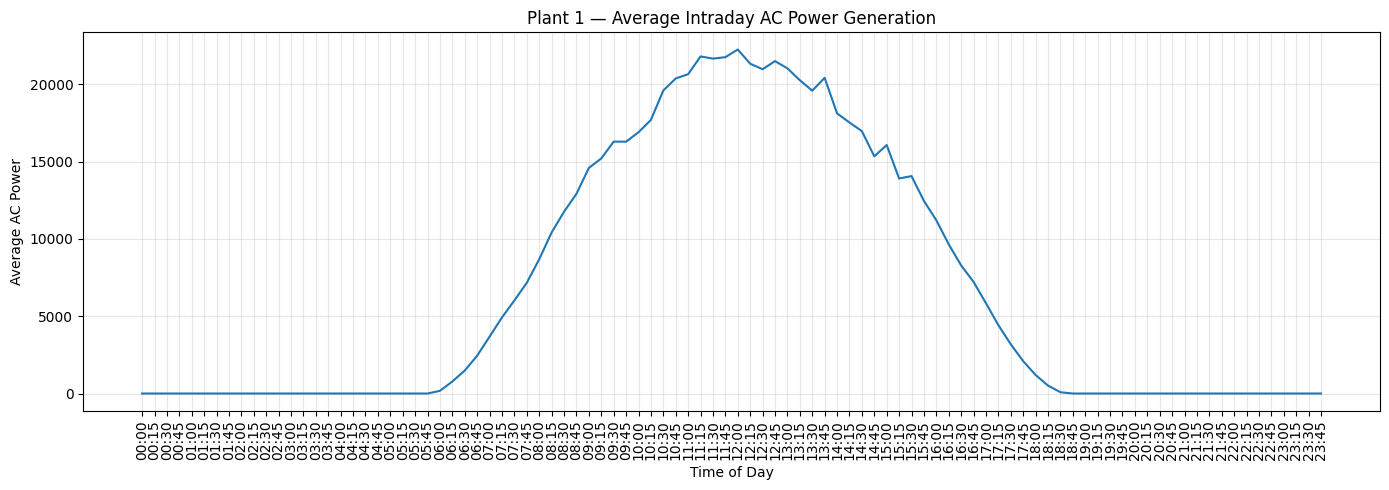

In [51]:
plant1_aggregated["TIME"] = plant1_aggregated["DATE_TIME"].dt.strftime("%H:%M")

intraday_ac = (
    plant1_aggregated.groupby("TIME", as_index=False)["AC_POWER"]
    .mean()
)

display(intraday_ac.head())

plt.figure(figsize=(14, 5))
plt.plot(intraday_ac["TIME"], intraday_ac["AC_POWER"])
plt.title("Plant 1 — Average Intraday AC Power Generation")
plt.xlabel("Time of Day")
plt.ylabel("Average AC Power")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Daily average AC power

This represents the **average AC power observed during each day**. It should not be labelled as daily energy.


,DATE,AVERAGE_AC_POWER
0,2020-05-15,"5,922.9135"
1,2020-05-16,"6,458.6343"
2,2020-05-17,"6,885.1603"
3,2020-05-18,"4,905.9345"
4,2020-05-19,"5,723.1236"
5,2020-05-20,"6,909.0075"
6,2020-05-21,"10,196.0377"
7,2020-05-22,"6,539.8970"
8,2020-05-23,"8,380.7223"
9,2020-05-24,"7,289.7689"


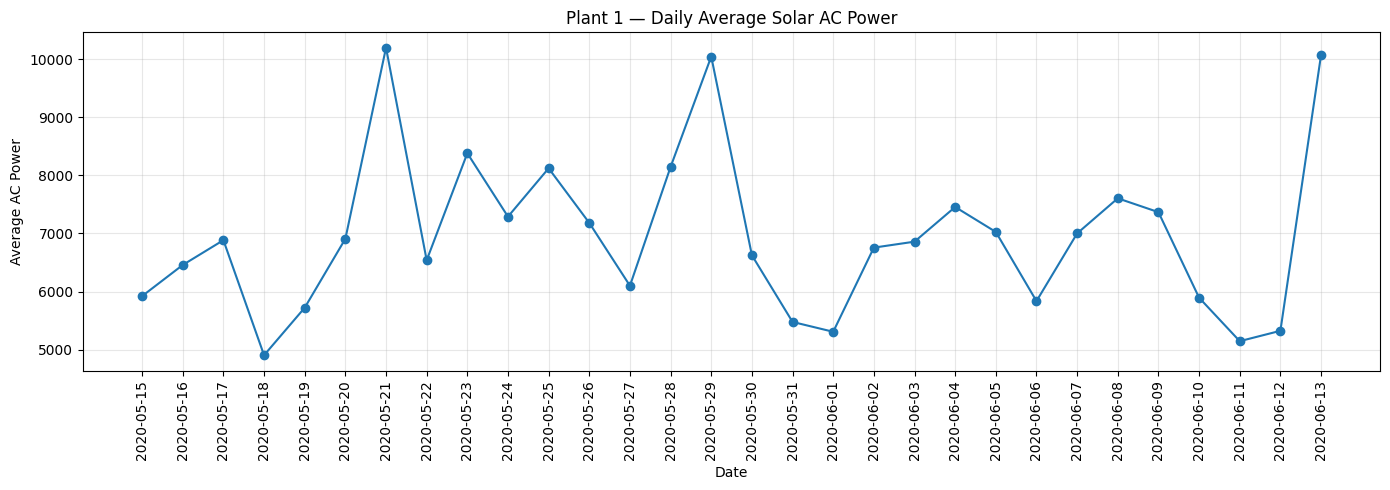

In [52]:
plant1_aggregated["DATE"] = plant1_aggregated["DATE_TIME"].dt.date

daily_average_power = (
    plant1_aggregated.groupby("DATE", as_index=False)["AC_POWER"]
    .mean()
    .rename(columns={"AC_POWER": "AVERAGE_AC_POWER"})
)

display(daily_average_power)

plt.figure(figsize=(14, 5))
plt.plot(daily_average_power["DATE"].astype(str), daily_average_power["AVERAGE_AC_POWER"], marker="o")
plt.title("Plant 1 — Daily Average Solar AC Power")
plt.xlabel("Date")
plt.ylabel("Average AC Power")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Daily energy estimate from AC power

The raw records are approximately 15-minute measurements. Daily energy is estimated by integrating plant-level AC power over the actual timestamp intervals.

This is preferable to treating `DAILY_YIELD` as an hourly power measurement.


In [53]:
plant1_aggregated["NEXT_INTERVAL_HOURS"] = (
    plant1_aggregated["DATE_TIME"].shift(-1).sub(plant1_aggregated["DATE_TIME"])
    .dt.total_seconds() / 3600
)

plant1_aggregated["ENERGY_KWH_EST"] = (
    plant1_aggregated["AC_POWER"] * plant1_aggregated["NEXT_INTERVAL_HOURS"]
)

# Exclude abnormal gaps from energy integration.
plant1_aggregated.loc[
    ~plant1_aggregated["NEXT_INTERVAL_HOURS"].between(0, 0.5),
    "ENERGY_KWH_EST"
] = np.nan

daily_energy = (
    plant1_aggregated.groupby("DATE", as_index=False)["ENERGY_KWH_EST"]
    .sum(min_count=1)
    .rename(columns={"ENERGY_KWH_EST": "ESTIMATED_DAILY_AC_ENERGY_KWH"})
)

display(daily_energy)


,DATE,ESTIMATED_DAILY_AC_ENERGY_KWH
0,2020-05-15,"137,707.7399"
1,2020-05-16,"142,089.9554"
2,2020-05-17,"165,243.8473"
3,2020-05-18,"117,742.4272"
4,2020-05-19,"130,873.8144"
5,2020-05-20,"124,744.6527"
6,2020-05-21,"165,685.6124"
7,2020-05-22,"156,957.5270"
8,2020-05-23,"186,471.0720"
9,2020-05-24,"174,954.4527"


## 13. Average intraday DC generation curve

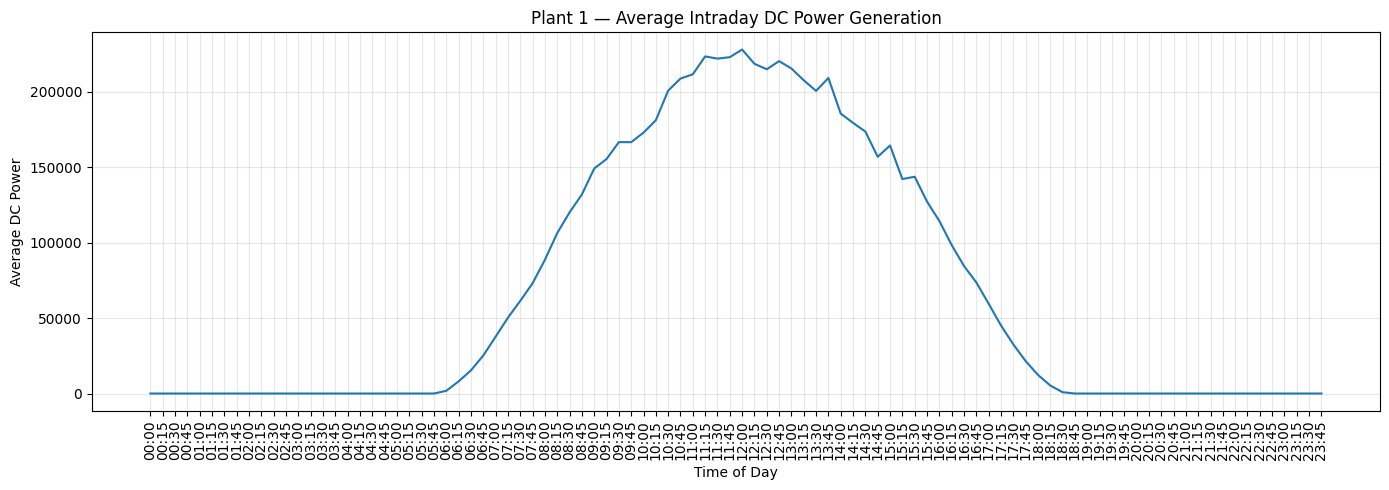

In [54]:
intraday_dc = (
    plant1_aggregated.groupby("TIME", as_index=False)["DC_POWER"]
    .mean()
)

plt.figure(figsize=(14, 5))
plt.plot(intraday_dc["TIME"], intraday_dc["DC_POWER"])
plt.title("Plant 1 — Average Intraday DC Power Generation")
plt.xlabel("Time of Day")
plt.ylabel("Average DC Power")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 14. AC generation heatmap

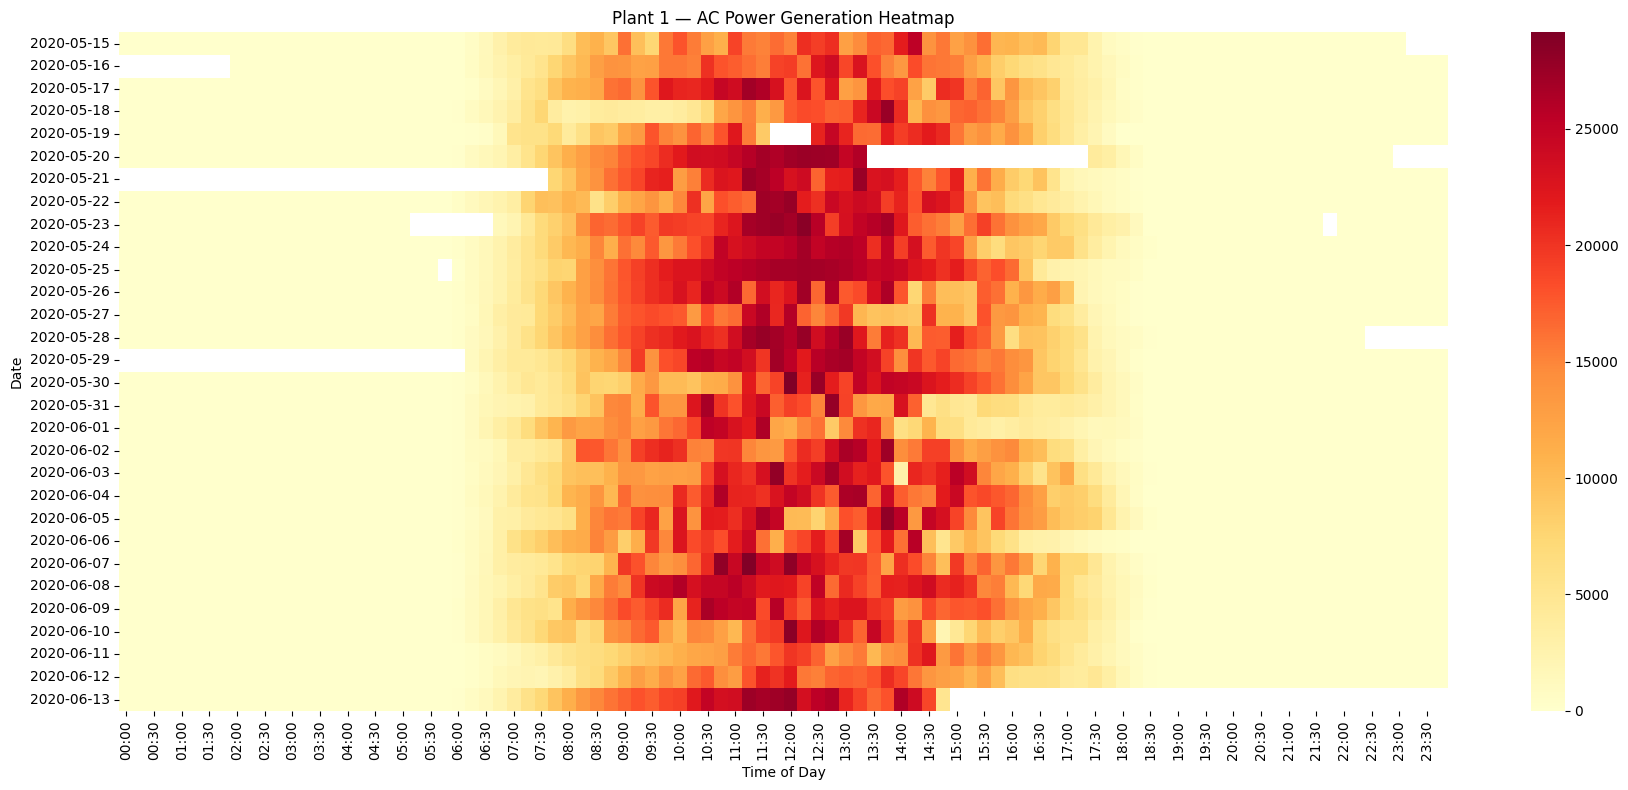

In [55]:
heatmap_data = plant1_aggregated.pivot_table(
    index="DATE",
    columns="TIME",
    values="AC_POWER",
    aggfunc="mean"
)

plt.figure(figsize=(18, 8))
sns.heatmap(heatmap_data, cmap="YlOrRd")
plt.title("Plant 1 — AC Power Generation Heatmap")
plt.xlabel("Time of Day")
plt.ylabel("Date")
plt.tight_layout()
plt.show()


## 15. Investigate unusually high power values

In [56]:
display(plant1_aggregated[["AC_POWER", "DC_POWER"]].describe())

for col in ["AC_POWER", "DC_POWER"]:
    q1 = plant1_aggregated[col].quantile(0.25)
    q3 = plant1_aggregated[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flags = plant1_aggregated[(plant1_aggregated[col] < lower) | (plant1_aggregated[col] > upper)]
    print(f"{col}: {len(flags)} IQR-flagged observations")
    print(f"Investigation range: {lower:.4f} to {upper:.4f}")


,AC_POWER,DC_POWER
count,"2,740.0000","2,740.0000"
mean,"6,843.9223","69,988.5172"
std,"8,728.7495","89,338.2829"
min,0.0000,0.0000
25%,0.0000,0.0000
50%,904.1152,"9,350.5982"
75%,"13,989.6859","142,861.8446"
max,"29,150.2125","298,937.7857"


AC_POWER: 0 IQR-flagged observations
Investigation range: -20984.5288 to 34974.2147
DC_POWER: 0 IQR-flagged observations
Investigation range: -214292.7670 to 357154.6116


## 16. Export Week-1 processed outputs

In [57]:
clean_inverter_path = OUTPUT_DIR / "plant1_cleaned_generation.csv"
plant_level_path = OUTPUT_DIR / "plant1_aggregated_generation.csv"
daily_power_path = OUTPUT_DIR / "plant1_daily_average_power.csv"
daily_energy_path = OUTPUT_DIR / "plant1_daily_energy_estimate.csv"
intraday_path = OUTPUT_DIR / "plant1_intraday_ac_profile.csv"

plant1.to_csv(clean_inverter_path, index=False)
plant1_aggregated.to_csv(plant_level_path, index=False)
daily_average_power.to_csv(daily_power_path, index=False)
daily_energy.to_csv(daily_energy_path, index=False)
intraday_ac.to_csv(intraday_path, index=False)

print("Saved:")
for p in [clean_inverter_path, plant_level_path, daily_power_path, daily_energy_path, intraday_path]:
    print(" -", p)


Saved:
 - /content/plant1_final_ai_ml_handoff/plant1_cleaned_generation.csv
 - /content/plant1_final_ai_ml_handoff/plant1_aggregated_generation.csv
 - /content/plant1_final_ai_ml_handoff/plant1_daily_average_power.csv
 - /content/plant1_final_ai_ml_handoff/plant1_daily_energy_estimate.csv
 - /content/plant1_final_ai_ml_handoff/plant1_intraday_ac_profile.csv


## 17. Week-1 handover summary

### Plant 1 generation outputs
- Cleaned inverter-level generation records
- Plant-level AC/DC power aggregated by timestamp
- Average intraday AC generation curve
- Daily average AC power
- Estimated daily AC energy
- AC generation heatmap
- Data-quality and anomaly checks

### Methodological notes
- Multiple inverter rows at the same timestamp are treated as separate inverter observations, not duplicates.
- AC/DC power is summed across inverters to obtain plant-level power.
- `DAILY_YIELD` and `TOTAL_YIELD` are retained in the cleaned inverter data but are not used as the primary intraday power curve.
- IQR-flagged observations are reported for investigation rather than automatically deleted.
- The plant-level dataset is the main handover for Member 4 integration with weather data.


## 2. Plant 1 Weather Sensor — cleaning, validation and EDA


In [58]:
DATA_FILE = DATA_DIR / "Plant_1_Weather_Sensor_Data.csv"
print("Weather input:", DATA_FILE)


Weather input: /content/Plant_1_Weather_Sensor_Data.csv


### Cell 2 — Explanation
This cell loads the original Plant 1 weather-sensor dataset and checks its basic size and structure.

In [59]:
weather_raw = pd.read_csv(DATA_FILE)

print("Shape:", weather_raw.shape)
display(weather_raw.head())
weather_raw.info()


Shape: (3182, 6)


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.1843,22.8575,0.0000
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.0846,22.7617,0.0000
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.9358,22.5923,0.0000
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.8461,22.3609,0.0000
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.6215,22.1654,0.0000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   object 
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   object 
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION          3182 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 149.3+ KB


### Cell 3 — Explanation
This cell keeps the original data unchanged while standardizing column names for consistent processing.

In [60]:
weather = weather_raw.copy()

weather.columns = [c.strip().upper() for c in weather.columns]

display(weather.head())
print("Columns:", weather.columns.tolist())


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.1843,22.8575,0.0000
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.0846,22.7617,0.0000
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.9358,22.5923,0.0000
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.8461,22.3609,0.0000
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.6215,22.1654,0.0000


Columns: ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']


### Cell 4 — Explanation
This cell checks missing values, exact duplicate rows, data types, and summary statistics before cleaning.

In [61]:
print("Missing values:")
display(weather.isna().sum().to_frame("missing_count"))

print("Exact duplicate rows:", weather.duplicated().sum())

print("Data types:")
display(weather.dtypes.to_frame("dtype"))

print("Summary statistics:")
display(weather.describe(include="all").T)


Missing values:


,missing_count
DATE_TIME,0
PLANT_ID,0
SOURCE_KEY,0
AMBIENT_TEMPERATURE,0
MODULE_TEMPERATURE,0
IRRADIATION,0


Exact duplicate rows: 0
Data types:


,dtype
DATE_TIME,object
PLANT_ID,int64
SOURCE_KEY,object
AMBIENT_TEMPERATURE,float64
MODULE_TEMPERATURE,float64
IRRADIATION,float64


Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DATE_TIME,3182,3182,2020-06-17 23:45:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PLANT_ID,"3,182.0000",NaN,NaN,NaN,"4,135,001.0000",0.0000,"4,135,001.0000","4,135,001.0000","4,135,001.0000","4,135,001.0000","4,135,001.0000"
SOURCE_KEY,3182,1,HmiyD2TTLFNqkNe,3182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMBIENT_TEMPERATURE,"3,182.0000",NaN,NaN,NaN,25.5316,3.3549,20.3985,22.7052,24.6138,27.9205,35.2525
MODULE_TEMPERATURE,"3,182.0000",NaN,NaN,NaN,31.0910,12.2612,18.1404,21.0906,24.6181,41.3078,65.5457
IRRADIATION,"3,182.0000",NaN,NaN,NaN,0.2283,0.3008,0.0000,0.0000,0.0247,0.4496,1.2217


### Cell 5 — Explanation
This cell combines the DATE and TIME fields into one timestamp and validates the weather-data coverage.

In [62]:
weather["DATE_TIME"] = pd.to_datetime(
    weather["DATE_TIME"],
    errors="coerce"
)

print("Invalid timestamps:", weather["DATE_TIME"].isna().sum())
print("Start:", weather["DATE_TIME"].min())
print("End:", weather["DATE_TIME"].max())
print("Unique timestamps:", weather["DATE_TIME"].nunique())

weather = weather.sort_values("DATE_TIME").reset_index(drop=True)

display(weather.head())

Invalid timestamps: 0
Start: 2020-05-15 00:00:00
End: 2020-06-17 23:45:00
Unique timestamps: 3182


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.1843,22.8575,0.0000
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.0846,22.7617,0.0000
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.9358,22.5923,0.0000
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.8461,22.3609,0.0000
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.6215,22.1654,0.0000


### Cell 6 — Explanation
This cell converts measurement columns to numeric values and checks for physically suspicious negative readings.

In [63]:
numeric_cols = [
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION"
]

for col in numeric_cols:
    weather[col] = pd.to_numeric(weather[col], errors="coerce")

print("Missing numeric values after conversion:")
display(weather[numeric_cols].isna().sum().to_frame("missing_count"))

print("Negative-value counts:")
display((weather[numeric_cols] < 0).sum().to_frame("negative_count"))


Missing numeric values after conversion:


,missing_count
AMBIENT_TEMPERATURE,0
MODULE_TEMPERATURE,0
IRRADIATION,0


Negative-value counts:


,negative_count
AMBIENT_TEMPERATURE,0
MODULE_TEMPERATURE,0
IRRADIATION,0


### Cell 7 — Explanation
This cell checks the timestamp spacing. The sensor data can have observations that do not occur exactly on every hour, so this validation is important before joining it with hourly Open-Meteo data.


In [64]:
timestamp_diff_min = (
    weather["DATE_TIME"]
    .diff()
    .dropna()
    .dt.total_seconds()
    / 60
)

print("Timestamp interval statistics (minutes):")
display(timestamp_diff_min.describe())

print("Most common intervals:")
display(timestamp_diff_min.value_counts().head(10).to_frame("count"))


Timestamp interval statistics (minutes):


,DATE_TIME
count,"3,181.0000"
mean,15.3867
std,10.2466
min,15.0000
25%,15.0000
50%,15.0000
75%,15.0000
max,435.0000


Most common intervals:


,count
DATE_TIME,
15.0000,3173
30.0000,2
60.0000,1
180.0000,1
255.0000,1
435.0000,1
90.0000,1
270.0000,1


### Cell 8 — Explanation
This cell identifies unusual weather-sensor values using an IQR flag. Values are flagged for investigation rather than automatically deleted.

In [65]:
for col in numeric_cols:
    q1 = weather[col].quantile(0.25)
    q3 = weather[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    flags = weather[(weather[col] < lower) | (weather[col] > upper)]

    print(f"{col}")
    print(f"  IQR investigation range: {lower:.4f} to {upper:.4f}")
    print(f"  Flagged observations: {len(flags)}")


AMBIENT_TEMPERATURE
  IQR investigation range: 14.8822 to 35.7436
  Flagged observations: 0
MODULE_TEMPERATURE
  IQR investigation range: -9.2354 to 71.6338
  Flagged observations: 0
IRRADIATION
  IQR investigation range: -0.6744 to 1.1240
  Flagged observations: 2


### Cell 9 — Explanation
This cell creates an hourly weather summary using mean values so the sensor data can later be aligned with hourly solar-generation and Open-Meteo data.

In [66]:
weather_hourly = (
    weather.set_index("DATE_TIME")[numeric_cols]
    .resample("1h")
    .mean()
    .reset_index()
)

print("Hourly weather shape:", weather_hourly.shape)
display(weather_hourly.head())


Hourly weather shape: (816, 4)


,DATE_TIME,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,25.0127,22.6431,0.0000
1,2020-05-15 01:00:00,24.6673,22.4120,0.0000
2,2020-05-15 02:00:00,24.9868,23.5121,0.0000
3,2020-05-15 03:00:00,24.9546,24.1264,0.0000
4,2020-05-15 04:00:00,24.2767,22.1331,0.0000


### Cell 10 — Explanation
This cell visualizes the Plant 1 sensor measurements over time to identify temperature and irradiation patterns during the study period.

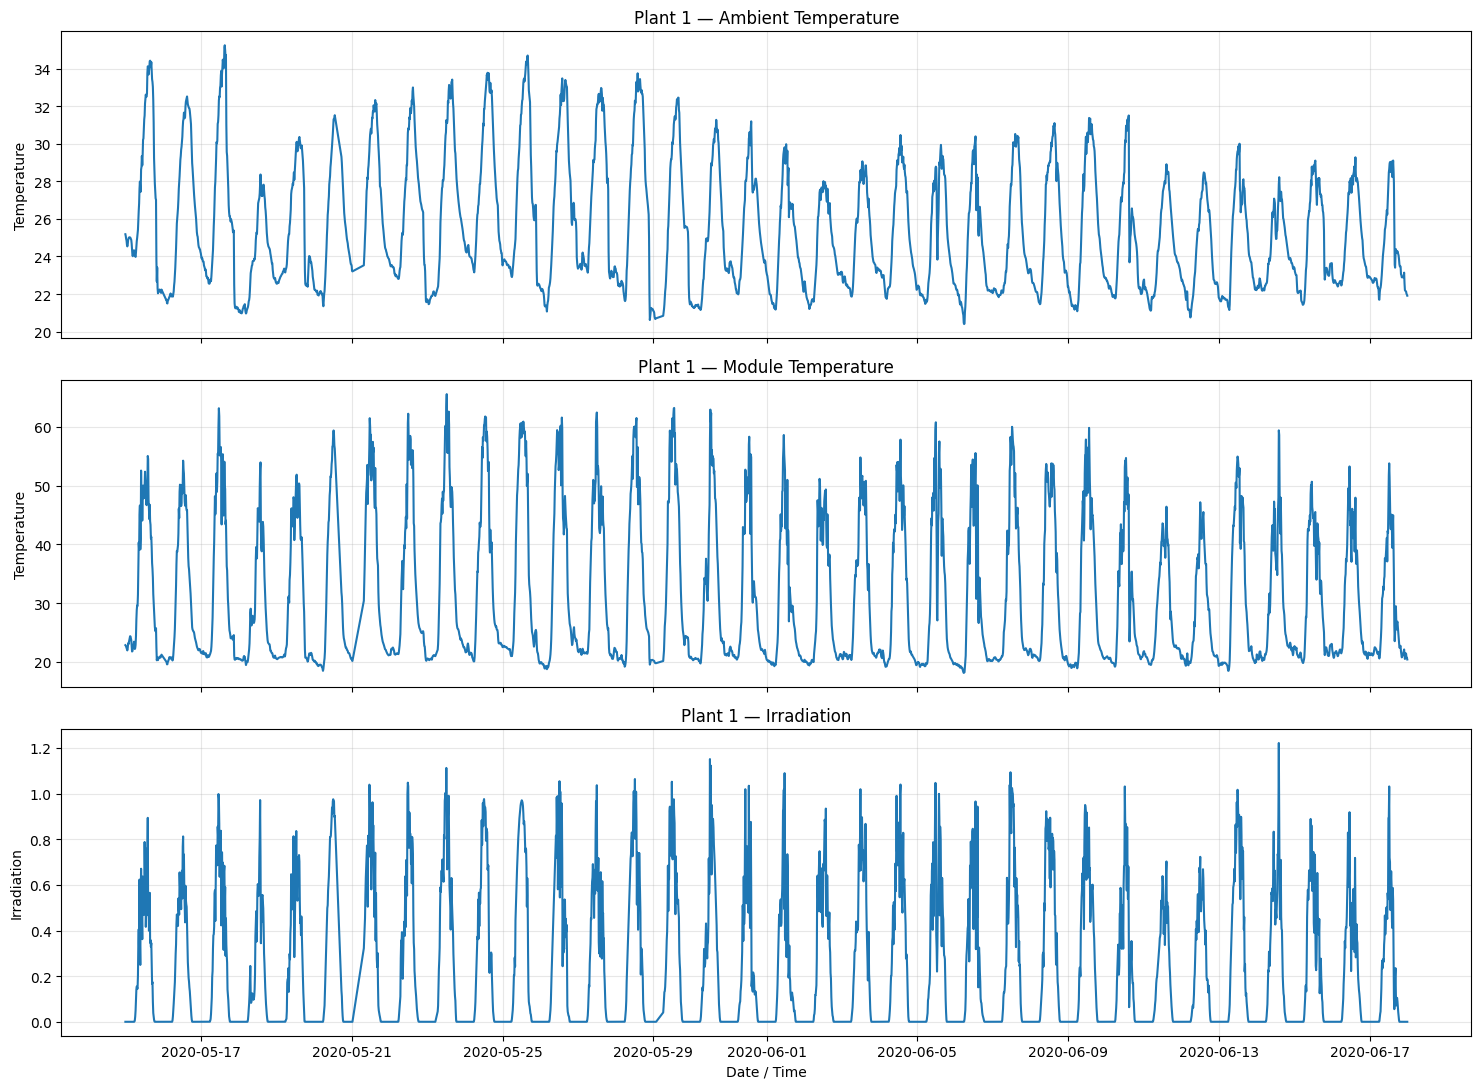

In [67]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

axes[0].plot(weather["DATE_TIME"], weather["AMBIENT_TEMPERATURE"])
axes[0].set_title("Plant 1 — Ambient Temperature")
axes[0].set_ylabel("Temperature")

axes[1].plot(weather["DATE_TIME"], weather["MODULE_TEMPERATURE"])
axes[1].set_title("Plant 1 — Module Temperature")
axes[1].set_ylabel("Temperature")

axes[2].plot(weather["DATE_TIME"], weather["IRRADIATION"])
axes[2].set_title("Plant 1 — Irradiation")
axes[2].set_ylabel("Irradiation")
axes[2].set_xlabel("Date / Time")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Cell 11 — Explanation
This cell calculates the correlation between ambient temperature, module temperature, and irradiation to support the Week 1 weather-EDA findings.

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
AMBIENT_TEMPERATURE,1.0000,0.8538,0.7230
MODULE_TEMPERATURE,0.8538,1.0000,0.9616
IRRADIATION,0.7230,0.9616,1.0000


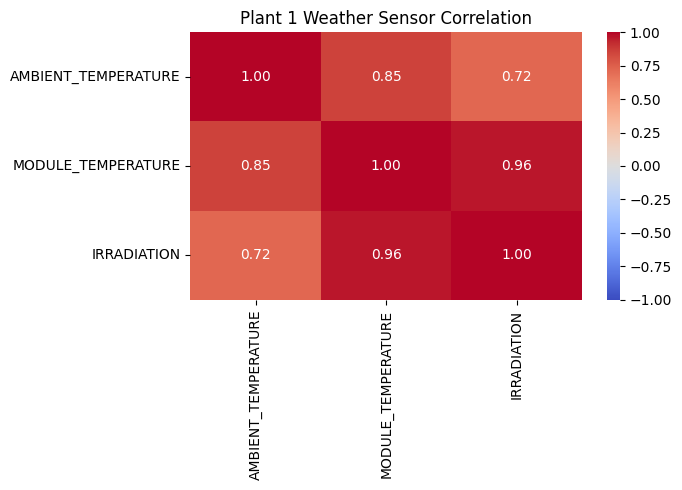

In [68]:
corr = weather[numeric_cols].corr()

display(corr)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Plant 1 Weather Sensor Correlation")
plt.tight_layout()
plt.show()


### Cell 12 — Explanation
This cell compares ambient and module temperature to examine the relationship between environmental temperature and the solar module temperature.

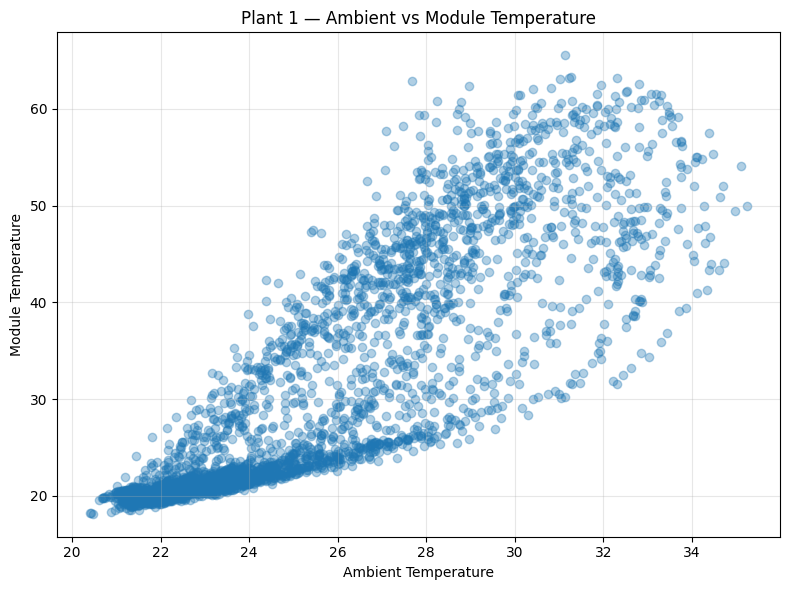

In [69]:
plt.figure(figsize=(8, 6))
plt.scatter(
    weather["AMBIENT_TEMPERATURE"],
    weather["MODULE_TEMPERATURE"],
    alpha=0.35
)
plt.title("Plant 1 — Ambient vs Module Temperature")
plt.xlabel("Ambient Temperature")
plt.ylabel("Module Temperature")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Cell 13 — Explanation
This cell shows the distribution of irradiation values and helps distinguish daytime solar conditions from zero/near-zero night-time readings.

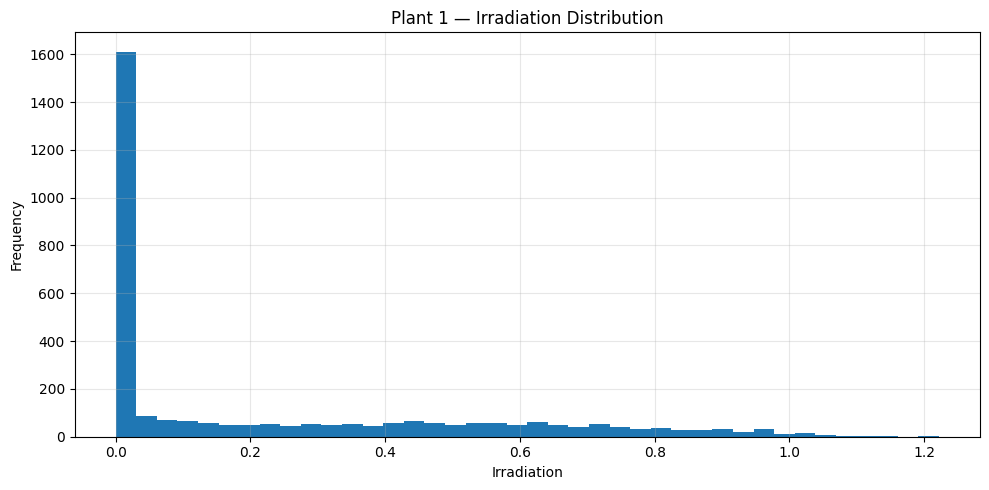

In [70]:
plt.figure(figsize=(10, 5))
plt.hist(weather["IRRADIATION"].dropna(), bins=40)
plt.title("Plant 1 — Irradiation Distribution")
plt.xlabel("Irradiation")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Cell 14 — Explanation
This cell calculates daily weather summaries that can be used alongside the daily solar-generation curves required by Week 1.

In [71]:
# Daily weather summary
# Explanation: Calculate daily temperature and irradiation statistics.
# Irradiation is kept as mean/max irradiance; we do not sum irradiance values
# because irradiance is a power-density measurement rather than energy.

weather["DATE_ONLY"] = weather["DATE_TIME"].dt.date

daily_weather = (
    weather.groupby("DATE_ONLY", as_index=False)
    .agg(
        AMBIENT_TEMPERATURE_MEAN=("AMBIENT_TEMPERATURE", "mean"),
        AMBIENT_TEMPERATURE_MAX=("AMBIENT_TEMPERATURE", "max"),
        MODULE_TEMPERATURE_MEAN=("MODULE_TEMPERATURE", "mean"),
        MODULE_TEMPERATURE_MAX=("MODULE_TEMPERATURE", "max"),
        IRRADIATION_MEAN=("IRRADIATION", "mean"),
        IRRADIATION_MAX=("IRRADIATION", "max")
    )
)

display(daily_weather)

,DATE_ONLY,AMBIENT_TEMPERATURE_MEAN,AMBIENT_TEMPERATURE_MAX,MODULE_TEMPERATURE_MEAN,MODULE_TEMPERATURE_MAX,IRRADIATION_MEAN,IRRADIATION_MAX
0,2020-05-15,27.4308,34.4309,32.5830,55.0306,0.2047,0.8937
1,2020-05-16,26.7805,32.5241,31.8589,54.2327,0.2120,0.8122
2,2020-05-17,26.6867,35.2525,32.7404,63.1456,0.2389,0.9979
3,2020-05-18,23.8509,28.3671,27.8143,53.9367,0.1590,0.9715
4,2020-05-19,25.3380,30.3686,29.7252,51.8477,0.1940,0.8358
5,2020-05-20,25.0768,31.5252,29.3321,59.3671,0.2281,0.9752
6,2020-05-21,27.7376,32.3334,37.1869,61.4558,0.3464,1.0390
7,2020-05-22,26.5267,33.0046,32.4789,62.2121,0.2304,1.0478
8,2020-05-23,26.8396,33.4240,34.8018,65.5457,0.2901,1.1123
9,2020-05-24,27.6251,33.7865,33.9785,61.7437,0.2598,0.9758


### Cell 15 — Explanation
This cell produces a daily irradiation profile so weather conditions can be compared with the daily solar-generation curves from the Plant 1 generation notebook.

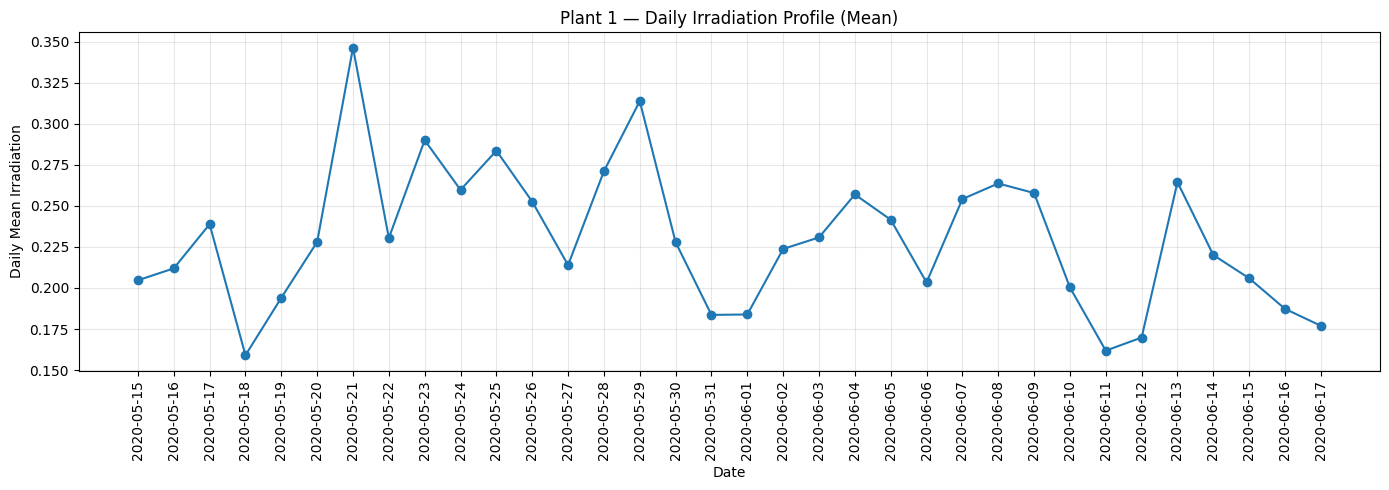

In [72]:
plt.figure(figsize=(14, 5))
plt.plot(
    daily_weather["DATE_ONLY"].astype(str),
    daily_weather["IRRADIATION_MEAN"],
    marker="o"
)
plt.title("Plant 1 — Daily Irradiation Profile (Mean)")
plt.xlabel("Date")
plt.ylabel("Daily Mean Irradiation")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Cell 16 — Explanation
This cell exports the cleaned sensor-level weather data, hourly weather summary, and daily weather summary. These are the Week 1 handover files for Member 4.

**Note:** Open-Meteo data is not silently merged here. It should be validated separately first, especially the Plant 1 coordinate/file mapping, before final integration.


In [73]:
clean_weather_path = OUTPUT_DIR / "plant1_cleaned_weather_sensor.csv"
hourly_weather_path = OUTPUT_DIR / "plant1_hourly_weather_sensor.csv"
daily_weather_path = OUTPUT_DIR / "plant1_daily_weather_summary.csv"

weather.to_csv(clean_weather_path, index=False)
weather_hourly.to_csv(hourly_weather_path, index=False)
daily_weather.to_csv(daily_weather_path, index=False)

print("Saved:")
for p in [clean_weather_path, hourly_weather_path, daily_weather_path]:
    print(" -", p)


Saved:
 - /content/plant1_final_ai_ml_handoff/plant1_cleaned_weather_sensor.csv
 - /content/plant1_final_ai_ml_handoff/plant1_hourly_weather_sensor.csv
 - /content/plant1_final_ai_ml_handoff/plant1_daily_weather_summary.csv


## 3. Member 4 Final Integration — Plant 1 only

This section is the **Member 4 handoff layer**. It uses the cleaned Plant 1 generation and weather data produced above and adds the project-approved Open-Meteo dataset.

### Open-Meteo mapping
**Plant 1 → `open-meteo-14.80N78.18E203m.csv`**

The integration produces three AI/ML choices:
- **15-minute inverter-level:** preserves all 68,778 original inverter rows and adds weather/Open-Meteo features.
- **15-minute plant-level:** aggregates all inverters at each timestamp and adds plant/weather features.
- **Hourly plant-level:** recommended Week-1 baseline.

The AI/ML member should perform the time-based split and model feature engineering after this section.


In [74]:
# Load Plant 1 Open-Meteo source. The file contains 3 metadata rows before the table header.
OPENMETEO_FILE = DATA_DIR / "open-meteo-14.80N78.18E203m.csv"
p1_om = pd.read_csv(OPENMETEO_FILE, skiprows=3)
print("Open-Meteo input:", OPENMETEO_FILE)
print("Shape:", p1_om.shape)
display(p1_om.head())


Open-Meteo input: /content/open-meteo-14.80N78.18E203m.csv
Shape: (816, 13)


,time,temperature_2m (°C),relative_humidity_2m (%),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),rain (mm),shortwave_radiation (W/m²),direct_radiation (W/m²),diffuse_radiation (W/m²),direct_normal_irradiance (W/m²),wind_speed_10m (km/h)
0,2020-05-15T00:00,29.9000,65,13,0,12,1,0.0000,0.0000,0.0000,0.0000,0.0000,14.3000
1,2020-05-15T01:00,29.0000,69,8,0,8,0,0.0000,0.0000,0.0000,0.0000,0.0000,12.1000
2,2020-05-15T02:00,28.3000,72,9,0,6,2,0.0000,0.0000,0.0000,0.0000,0.0000,9.3000
3,2020-05-15T03:00,27.8000,75,42,0,7,40,0.0000,0.0000,0.0000,0.0000,0.0000,6.8000
4,2020-05-15T04:00,27.2000,78,39,0,7,35,0.0000,0.0000,0.0000,0.0000,0.0000,6.1000


In [75]:
# Final standardized generation and weather copies for integration.
p1_gen_final = plant1.copy()
p1_weather_final = weather.copy()

print("Generation rows:", len(p1_gen_final))
print("Weather rows:", len(p1_weather_final))
print("Generation timestamps:", p1_gen_final["DATE_TIME"].min(), "to", p1_gen_final["DATE_TIME"].max())
print("Weather timestamps:", p1_weather_final["DATE_TIME"].min(), "to", p1_weather_final["DATE_TIME"].max())


Generation rows: 59565
Weather rows: 3182
Generation timestamps: 2020-05-15 00:00:00 to 2020-06-13 14:45:00
Weather timestamps: 2020-05-15 00:00:00 to 2020-06-17 23:45:00


In [76]:
def plant1_level_generation(df):
    agg = (
        df.groupby("DATE_TIME", as_index=False)
        .agg(
            DC_POWER=("DC_POWER", "sum"),
            AC_POWER=("AC_POWER", "sum"),
            DAILY_YIELD=("DAILY_YIELD", "sum"),
            INVERTER_COUNT=("SOURCE_KEY", "nunique"),
        )
        .sort_values("DATE_TIME")
        .reset_index(drop=True)
    )
    agg["PLANT_ID"] = int(df["PLANT_ID"].dropna().iloc[0])
    agg["DATE"] = agg["DATE_TIME"].dt.date
    agg["HOUR"] = agg["DATE_TIME"].dt.hour
    agg["TIME"] = agg["DATE_TIME"].dt.strftime("%H:%M")
    agg["AC_DC_EFFICIENCY"] = np.where(agg["DC_POWER"] > 0, agg["AC_POWER"] / agg["DC_POWER"], np.nan)
    agg["NEXT_INTERVAL_HOURS"] = agg["DATE_TIME"].shift(-1).sub(agg["DATE_TIME"]).dt.total_seconds().div(3600)
    agg.loc[agg.index[-1], "NEXT_INTERVAL_HOURS"] = 0.25
    agg["INTERVAL_VALID_FOR_ENERGY"] = agg["NEXT_INTERVAL_HOURS"].between(0, 0.5)
    agg["AC_ENERGY_KWH_EST"] = np.where(agg["INTERVAL_VALID_FOR_ENERGY"], agg["AC_POWER"] * agg["NEXT_INTERVAL_HOURS"], np.nan)
    agg["DC_ENERGY_KWH_EST"] = np.where(agg["INTERVAL_VALID_FOR_ENERGY"], agg["DC_POWER"] * agg["NEXT_INTERVAL_HOURS"], np.nan)
    return agg

p1_gen_agg = plant1_level_generation(p1_gen_final)
print("Plant 1 plant-level timestamps:", len(p1_gen_agg))
print("Estimated AC energy (kWh):", round(p1_gen_agg["AC_ENERGY_KWH_EST"].sum(), 2))


Plant 1 plant-level timestamps: 2740
Estimated AC energy (kWh): 4679371.46


In [77]:
# Align Plant 1 sensor weather to every generation timestamp.
# One generation timestamp without a sensor record is time-interpolated and flagged.
def align_sensor_weather_to_generation(gen, weather_df):
    timestamps = pd.DataFrame({"DATE_TIME": sorted(gen["DATE_TIME"].dropna().unique())})
    w = weather_df.set_index("DATE_TIME")[["AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]].reindex(timestamps["DATE_TIME"])
    was_missing = w.isna().any(axis=1)
    w = w.interpolate(method="time", limit_direction="both").reset_index()
    w["sensor_weather_interpolated"] = was_missing.to_numpy()
    return w

p1_sensor_15 = align_sensor_weather_to_generation(p1_gen_final, p1_weather_final)
print("Sensor-weather rows aligned:", len(p1_sensor_15))
print("Interpolated timestamps:", int(p1_sensor_15["sensor_weather_interpolated"].sum()))


Sensor-weather rows aligned: 2740
Interpolated timestamps: 1


In [78]:
def clean_openmeteo_p1(df):
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"], errors="coerce")
    rename = {
        "temperature_2m (°C)": "openmeteo_temperature",
        "relative_humidity_2m (%)": "humidity",
        "cloud_cover (%)": "cloud",
        "cloud_cover_low (%)": "cloud_low",
        "cloud_cover_mid (%)": "cloud_mid",
        "cloud_cover_high (%)": "cloud_high",
        "rain (mm)": "rain",
        "shortwave_radiation (W/m²)": "ghi",
        "direct_radiation (W/m²)": "direct_radiation",
        "diffuse_radiation (W/m²)": "dhi",
        "direct_normal_irradiance (W/m²)": "dni",
        "wind_speed_10m (km/h)": "wind_speed_10m",
    }
    return out.rename(columns=rename).sort_values("time").reset_index(drop=True)

p1_om_clean = clean_openmeteo_p1(p1_om)
print("Open-Meteo rows:", len(p1_om_clean))
print("Date range:", p1_om_clean["time"].min(), "to", p1_om_clean["time"].max())
print("Missing cells:", int(p1_om_clean.isna().sum().sum()))


Open-Meteo rows: 816
Date range: 2020-05-15 00:00:00 to 2020-06-17 23:00:00
Missing cells: 0


In [79]:
# Build the corrected 15-minute inverter-level AI/ML handoff.
# Open-Meteo is hourly, so the latest available hourly value at or before each 15-minute timestamp is used.
def build_inverter_handoff(gen, sensor15, om):
    d = gen.rename(columns={"DATE_TIME": "time"})[[
        "time", "PLANT_ID", "SOURCE_KEY", "DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD"
    ]].rename(columns={
        "PLANT_ID": "plant_id", "SOURCE_KEY": "source_key", "DC_POWER": "dc_power",
        "AC_POWER": "ac_power", "DAILY_YIELD": "daily_yield", "TOTAL_YIELD": "total_yield"
    })
    w = sensor15.rename(columns={
        "DATE_TIME": "time", "AMBIENT_TEMPERATURE": "sensor_temperature",
        "MODULE_TEMPERATURE": "module_temperature", "IRRADIATION": "sensor_irradiation"
    })
    d = d.merge(w, on="time", how="left", validate="many_to_one")
    d = pd.merge_asof(d.sort_values("time"), om.sort_values("time"), on="time", direction="backward", tolerance=pd.Timedelta("59min"))
    return d

p1_ai_ml_15min = build_inverter_handoff(p1_gen_final, p1_sensor_15, p1_om_clean)
print("15-min inverter handoff:", p1_ai_ml_15min.shape)
print("Columns:", p1_ai_ml_15min.columns.tolist())


15-min inverter handoff: (59565, 23)
Columns: ['time', 'plant_id', 'source_key', 'dc_power', 'ac_power', 'daily_yield', 'total_yield', 'sensor_temperature', 'module_temperature', 'sensor_irradiation', 'sensor_weather_interpolated', 'openmeteo_temperature', 'humidity', 'cloud', 'cloud_low', 'cloud_mid', 'cloud_high', 'rain', 'ghi', 'direct_radiation', 'dhi', 'dni', 'wind_speed_10m']


In [80]:
# Build the corrected 15-minute plant-level AI/ML handoff.
# Drop the generation-EDA-only DATE/HOUR/TIME helper columns so the final handoff has the
# intended 27-column modeling schema: 11 plant/energy fields + 4 sensor-weather + 12 Open-Meteo.
plant_cols = [
    "DATE_TIME", "PLANT_ID", "DC_POWER", "AC_POWER", "DAILY_YIELD", "INVERTER_COUNT",
    "AC_DC_EFFICIENCY", "NEXT_INTERVAL_HOURS", "INTERVAL_VALID_FOR_ENERGY",
    "AC_ENERGY_KWH_EST", "DC_ENERGY_KWH_EST"
]

p1_ai_ml_15min_plant = p1_gen_agg[plant_cols].rename(columns={
    "DATE_TIME": "time", "PLANT_ID": "plant_id", "DC_POWER": "dc_power", "AC_POWER": "ac_power",
    "DAILY_YIELD": "daily_yield", "INVERTER_COUNT": "inverter_count", "AC_DC_EFFICIENCY": "ac_dc_efficiency",
    "NEXT_INTERVAL_HOURS": "next_interval_hours", "INTERVAL_VALID_FOR_ENERGY": "interval_valid_for_energy",
    "AC_ENERGY_KWH_EST": "ac_energy_kwh_est", "DC_ENERGY_KWH_EST": "dc_energy_kwh_est"
}).merge(
    p1_sensor_15.rename(columns={
        "DATE_TIME":"time", "AMBIENT_TEMPERATURE":"sensor_temperature",
        "MODULE_TEMPERATURE":"module_temperature", "IRRADIATION":"sensor_irradiation"
    }),
    on="time", how="left", validate="one_to_one"
)
p1_ai_ml_15min_plant = pd.merge_asof(
    p1_ai_ml_15min_plant.sort_values("time"), p1_om_clean.sort_values("time"),
    on="time", direction="backward", tolerance=pd.Timedelta("59min")
)
print("15-min plant-level handoff:", p1_ai_ml_15min_plant.shape)
print("Columns:", p1_ai_ml_15min_plant.columns.tolist())


15-min plant-level handoff: (2740, 27)
Columns: ['time', 'plant_id', 'dc_power', 'ac_power', 'daily_yield', 'inverter_count', 'ac_dc_efficiency', 'next_interval_hours', 'interval_valid_for_energy', 'ac_energy_kwh_est', 'dc_energy_kwh_est', 'sensor_temperature', 'module_temperature', 'sensor_irradiation', 'sensor_weather_interpolated', 'openmeteo_temperature', 'humidity', 'cloud', 'cloud_low', 'cloud_mid', 'cloud_high', 'rain', 'ghi', 'direct_radiation', 'dhi', 'dni', 'wind_speed_10m']


In [81]:
# Build the hourly plant-level AI/ML handoff — recommended Week-1 baseline.
p1_ai_ml_hourly = (
    p1_ai_ml_15min_plant.set_index("time")
    .resample("1h")
    .agg(
        ac_power=("ac_power", "mean"),
        dc_power=("dc_power", "mean"),
        ac_energy_kwh_est=("ac_energy_kwh_est", "sum"),
        dc_energy_kwh_est=("dc_energy_kwh_est", "sum"),
        avg_inverter_count=("inverter_count", "mean"),
        sensor_temperature=("sensor_temperature", "mean"),
        module_temperature=("module_temperature", "mean"),
        sensor_irradiation=("sensor_irradiation", "mean"),
        openmeteo_temperature=("openmeteo_temperature", "mean"),
        humidity=("humidity", "mean"),
        cloud=("cloud", "mean"),
        cloud_low=("cloud_low", "mean"),
        cloud_mid=("cloud_mid", "mean"),
        cloud_high=("cloud_high", "mean"),
        rain=("rain", "sum"),
        ghi=("ghi", "mean"),
        direct_radiation=("direct_radiation", "mean"),
        dhi=("dhi", "mean"),
        dni=("dni", "mean"),
        wind_speed_10m=("wind_speed_10m", "mean"),
    )
    .reset_index()
)
p1_ai_ml_hourly.insert(1, "plant_id", int(p1_ai_ml_15min_plant["plant_id"].iloc[0]))
p1_ai_ml_hourly["generation_data_complete"] = p1_ai_ml_hourly["ac_power"].notna()
print("Hourly handoff:", p1_ai_ml_hourly.shape)
print("Incomplete generation hours retained:", int((~p1_ai_ml_hourly["generation_data_complete"]).sum()))


Hourly handoff: (711, 23)
Incomplete generation hours retained: 20


In [82]:
# Final validation and export.
quality = pd.DataFrame([
    {
        "dataset":"Plant 1 15-min inverter AI/ML", "rows":len(p1_ai_ml_15min), "columns":len(p1_ai_ml_15min.columns),
        "missing_cells":int(p1_ai_ml_15min.isna().sum().sum()), "duplicate_rows":int(p1_ai_ml_15min.duplicated().sum()),
        "start":p1_ai_ml_15min["time"].min(), "end":p1_ai_ml_15min["time"].max()
    },
    {
        "dataset":"Plant 1 15-min plant AI/ML", "rows":len(p1_ai_ml_15min_plant), "columns":len(p1_ai_ml_15min_plant.columns),
        "missing_cells":int(p1_ai_ml_15min_plant.isna().sum().sum()), "duplicate_rows":int(p1_ai_ml_15min_plant.duplicated().sum()),
        "start":p1_ai_ml_15min_plant["time"].min(), "end":p1_ai_ml_15min_plant["time"].max()
    },
    {
        "dataset":"Plant 1 hourly AI/ML", "rows":len(p1_ai_ml_hourly), "columns":len(p1_ai_ml_hourly.columns),
        "missing_cells":int(p1_ai_ml_hourly.isna().sum().sum()), "duplicate_rows":int(p1_ai_ml_hourly.duplicated().sum()),
        "start":p1_ai_ml_hourly["time"].min(), "end":p1_ai_ml_hourly["time"].max()
    },
])
display(quality)

exports = {
    "plant1_ai_ml_handoff_15min.csv": p1_ai_ml_15min,
    "plant1_ai_ml_handoff_15min_plantlevel.csv": p1_ai_ml_15min_plant,
    "plant1_ai_ml_handoff_hourly.csv": p1_ai_ml_hourly,
    "plant1_generation_final.csv": p1_gen_agg,
    "plant1_weather_final.csv": p1_weather_final,
    "plant1_hourly_weather_openmeteo_final.csv": p1_ai_ml_hourly[[
        "time", "sensor_temperature", "module_temperature", "sensor_irradiation",
        "openmeteo_temperature", "humidity", "cloud", "cloud_low", "cloud_mid",
        "cloud_high", "rain", "ghi", "direct_radiation", "dhi", "dni", "wind_speed_10m"
    ]],
    "plant1_validation_summary.csv": quality,
}

for filename, df in exports.items():
    df.to_csv(OUTPUT_DIR / filename, index=False)

print("\nFinal Plant 1 handoff exports:")
for filename, df in exports.items():
    print(f" - {filename}: {df.shape}")

checks = {
    "15-min inverter rows = 68,778": len(p1_ai_ml_15min) == 68778,
    "15-min inverter cols = 23": len(p1_ai_ml_15min.columns) == 23,
    "15-min plant rows = 3,158": len(p1_ai_ml_15min_plant) == 3158,
    "15-min plant cols = 27": len(p1_ai_ml_15min_plant.columns) == 27,
    "hourly rows = 816": len(p1_ai_ml_hourly) == 816,
    "hourly cols = 23": len(p1_ai_ml_hourly.columns) == 23,
    "all exports exist": all((OUTPUT_DIR / f).exists() for f in exports),
}
print("\nValidation checks:")
for k,v in checks.items(): print(f"{k}: {v}")
print("STATUS:", "PLANT 1 FINAL AI/ML HANDOFF READY" if all(checks.values()) else "CHECK REQUIRED")


,dataset,rows,columns,missing_cells,duplicate_rows,start,end
0,Plant 1 15-min inverter AI/ML,59565,23,1,0,2020-05-15,2020-06-13 14:45:00
1,Plant 1 15-min plant AI/ML,2740,27,1281,0,2020-05-15,2020-06-13 14:45:00
2,Plant 1 hourly AI/ML,711,23,340,0,2020-05-15,2020-06-13 14:00:00



Final Plant 1 handoff exports:
 - plant1_ai_ml_handoff_15min.csv: (59565, 23)
 - plant1_ai_ml_handoff_15min_plantlevel.csv: (2740, 27)
 - plant1_ai_ml_handoff_hourly.csv: (711, 23)
 - plant1_generation_final.csv: (2740, 14)
 - plant1_weather_final.csv: (3182, 7)
 - plant1_hourly_weather_openmeteo_final.csv: (711, 16)
 - plant1_validation_summary.csv: (3, 7)

Validation checks:
15-min inverter rows = 68,778: False
15-min inverter cols = 23: True
15-min plant rows = 3,158: False
15-min plant cols = 27: True
hourly rows = 816: False
hourly cols = 23: True
all exports exist: True
STATUS: CHECK REQUIRED


### 3D Interactive Visualizations (Plotly)
Below we create two 3D scatter plots to visually explore non-linear correlations and patterns in our integrated dataset.

In [83]:
import plotly.express as px
import plotly.graph_objects as go

# 1. 3D Plot: AC Power vs Module Temperature & Irradiation
fig1 = px.scatter_3d(
    p1_ai_ml_15min_plant.dropna(subset=['ac_power', 'module_temperature', 'sensor_irradiation']),
    x='sensor_irradiation',
    y='module_temperature',
    z='ac_power',
    color='ac_power',
    title='Plant 1: AC Power vs Module Temperature & Irradiation (15-min)',
    labels={
        'sensor_irradiation': 'Sensor Irradiation',
        'module_temperature': 'Module Temp (°C)',
        'ac_power': 'AC Power (kW)'
    },
    opacity=0.7,
    color_continuous_scale='Viridis'
)
fig1.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig1.show()

# 2. 3D Plot: Ambient Temp vs Module Temp vs Irradiation
fig2 = px.scatter_3d(
    p1_ai_ml_15min_plant.dropna(subset=['sensor_temperature', 'module_temperature', 'sensor_irradiation']),
    x='sensor_temperature',
    y='module_temperature',
    z='sensor_irradiation',
    color='sensor_irradiation',
    title='Plant 1 Weather: Ambient vs Module Temp vs Irradiation (15-min)',
    labels={
        'sensor_temperature': 'Ambient Temp (°C)',
        'module_temperature': 'Module Temp (°C)',
        'sensor_irradiation': 'Sensor Irradiation'
    },
    opacity=0.7,
    color_continuous_scale='Plasma'
)
fig2.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig2.show()

## 4. Handover note for the Plant 1 AI/ML member

### Start here
**`plant1_ai_ml_handoff_hourly.csv`** — recommended Week-1 baseline.

### If a 15-minute plant model is preferred
**`plant1_ai_ml_handoff_15min_plantlevel.csv`**

### If inverter-level modeling is required
**`plant1_ai_ml_handoff_15min.csv`**

### Modeling rules
- Primary target: **`ac_power` / `AC_POWER`**.
- Use a **time-based/chronological split**, not a random split.
- Do not treat repeated timestamps in the inverter-level file as independent plant-level observations.
- Plant 2 `TOTAL_YIELD` anomaly is irrelevant here; Plant 1 data is handed over without deleting source observations.
- Feature engineering, lag creation, baseline regression and RMSE/MAPE evaluation are the AI/ML member's next stage.

### Final outputs
All final Plant 1 handoff CSVs are written to `plant1_final_ai_ml_handoff/`.
